In [1]:
import pandas as pd
import requests
import psycopg2
from tqdm import tqdm
import re
import os
import psycopg2.extras
import seaborn as sns
import matplotlib.pyplot as plt
import ast

In [2]:
quran_csv = "rag_dataset.csv"
quran_csv

'rag_dataset.csv'

In [26]:
OLLAMA_URL = "http://localhost:11434"
MODEL_NAME = "llama3.2"

EMBEDDING_MODELS = [
    {"name": "nomic-embed-text"},
    {"name": "embeddinggemma:300m"},
    {"name": "snowflake-arctic-embed2:568m"},
    {"name": "dengcao/Qwen3-Embedding-0.6B:Q8_0"},
    {"name": "qwen3-embedding:8b"}
]

emb_tables =[
    {"name": "embeddings_nomic_embed_text"},
    {"name": "embeddings_embeddinggemma_300m"},
    {"name": "embeddings_snowflake_arctic_embed2_568m"},
    {"name": "embeddings_dengcao_qwen3_embedding_0_6b_q8_0"},
    {"name": "embeddings_qwen3_embedding_8b"}
]
TOP_K = 20
NUM_ROWS = 50
QUESTION_DISTRIBUTION = {
    "short": 5,
    "long": 5,
    "direct": 5,
    "implied": 5,
    "unclear": 5
}


In [4]:
DATABASE_PARAMS = {
    "dbname": "ragdb",
    "user": "rag",
    "password": "rag",
    "host": "localhost",
    "port": 5432
}

In [5]:
def connect_db():
    return psycopg2.connect(**DATABASE_PARAMS)

In [6]:
with connect_db() as conn:
    with conn.cursor() as cur:
        cur.execute("DROP TABLE IF EXISTS quran_docs CASCADE;")
        cur.execute("DROP TABLE IF EXISTS quran_tafseer CASCADE;")
    conn.commit()
print("Old tables dropped.")

Old tables dropped.


In [7]:
with connect_db() as conn:
    with conn.cursor() as cur:
        cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")

        cur.execute(f"""
            CREATE TABLE IF NOT EXISTS quran_tafseer (
                id SERIAL PRIMARY KEY,
                surah_name TEXT,
                surah_number INT,
                ayah_no INT,
                ayah_ar TEXT,
                ayah_and_tafseer TEXT NOT NULL
            );
        """)


In [8]:
df = pd.read_csv(quran_csv)
with connect_db() as conn:
    with conn.cursor() as cur:
        for _, row in df.iterrows():
            cur.execute("""
                INSERT INTO quran_tafseer (surah_name, surah_number, ayah_no, ayah_ar, ayah_and_tafseer)
                VALUES (%s, %s, %s, %s, %s)
                RETURNING id;
            """, (
                row['surah_name'],
                row['surah_number'],
                row['ayah_no'],
                row['ayah_ar'],
                row['ayah_and_tafseer']
            ))
print(f"{len(df)} rows inserted into quran_tafseer.")

6236 rows inserted into quran_tafseer.


In [9]:
with conn.cursor() as cur:
    cur.execute("SELECT * FROM quran_tafseer LIMIT 1;")
    print(cur.fetchone())

(1, 'Al-Fatihah', 1, 1, 'بِسْمِ ٱللَّهِ ٱلرَّحْمَٰنِ ٱلرَّحِيمِ', 'ayah: in the name of allah—the most compassionate, most merciful.tafseer: in the name of god the compassionate the merciful')


In [10]:
def sanitize_table_name(name: str) -> str:
    sanitized = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    if re.match(r'^\d', sanitized):
        sanitized = 't_' + sanitized
    return sanitized.lower()

def create_embeddings_table(model_name: str, vector_dim: int) -> str:
    table_name = f"embeddings_{sanitize_table_name(model_name)}"

    create_sql = f"""
    CREATE TABLE IF NOT EXISTS {table_name} (
        id SERIAL PRIMARY KEY,
        quran_tafseer_id INT UNIQUE,
        embedding REAL[]
    );
    """
    with connect_db() as conn:
        with conn.cursor() as cur:
            cur.execute(create_sql)
        conn.commit()

    return table_name


In [11]:
def get_embedding_ollama(model_name, text):
    resp = requests.post(
        f"{OLLAMA_URL}/api/embeddings",
        json={"model": model_name, "prompt": text}
    )
    resp.raise_for_status()
    return resp.json()["embedding"]

In [12]:
def generate_embeddings(model_name):
    with connect_db() as conn:
        with conn.cursor() as cur:
            cur.execute("SELECT id, ayah_and_tafseer FROM quran_tafseer;")
            rows = cur.fetchall()

    if not rows:
        print("No rows found in quran_docs.")
        return

    sample_emb = get_embedding_ollama(model_name, rows[0][1])
    vector_dim = len(sample_emb)
    print(f"Detected embedding dimension: {vector_dim}")

    table_name = create_embeddings_table(model_name, vector_dim)
    print(f"Embeddings table created: {table_name}")

    with connect_db() as conn:
        with conn.cursor() as cur:
            for doc_id, text in tqdm(rows, desc=f"Generating embeddings for {model_name}"):
                # Skip if already exists
                cur.execute(f"SELECT id FROM {table_name} WHERE quran_tafseer_id=%s", (doc_id,))
                if cur.fetchone():
                    continue

                emb = get_embedding_ollama(model_name, text)
                cur.execute(f"""
                    INSERT INTO {table_name} (quran_tafseer_id, embedding)
                    VALUES (%s, %s)
                """, (doc_id, emb))
        conn.commit()
    print(f"All embeddings inserted for model '{model_name}'")


In [14]:
for model in ["nomic-embed-text","embeddinggemma:300m","snowflake-arctic-embed2:568m", "dengcao/Qwen3-Embedding-0.6B:Q8_0","qwen3-embedding:8b"]:
    generate_embeddings(model)


Detected embedding dimension: 768
Embeddings table created: embeddings_nomic_embed_text


Generating embeddings for nomic-embed-text: 100%|██████████| 6236/6236 [00:08<00:00, 722.61it/s]


All embeddings inserted for model 'nomic-embed-text'
Detected embedding dimension: 768
Embeddings table created: embeddings_embeddinggemma_300m


Generating embeddings for embeddinggemma:300m: 100%|██████████| 6236/6236 [00:06<00:00, 1028.17it/s]


All embeddings inserted for model 'embeddinggemma:300m'
Detected embedding dimension: 1024
Embeddings table created: embeddings_snowflake_arctic_embed2_568m


...

All embeddings inserted for model 'snowflake-arctic-embed2:568m'
Detected embedding dimension: 1024
Embeddings table created: embeddings_dengcao_qwen3_embedding_0_6b_q8_0


Generating embeddings for dengcao/Qwen3-Embedding-0.6B:Q8_0: 100%|██████████| 6236/6236 [00:05<00:00, 1061.04it/s]


All embeddings inserted for model 'dengcao/Qwen3-Embedding-0.6B:Q8_0'
Detected embedding dimension: 4096
Embeddings table created: embeddings_qwen3_embedding_8b


Generating embeddings for qwen3-embedding:8b: 100%|██████████| 6236/6236 [22:49<00:00,  4.55it/s]

All embeddings inserted for model 'qwen3-embedding:8b'


In [15]:
with connect_db() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT table_name
            FROM information_schema.tables
            WHERE table_schema='public';
        """)
        tables = cur.fetchall()
        print("Tables in database:")
        print("___________________")
        for t in tables:
            print(t[0])


Tables in database:
___________________
embeddings_nomic_embed_text
embeddings_embeddinggemma_300m
embeddings_snowflake_arctic_embed2_568m
embeddings_dengcao_qwen3_embedding_0_6b_q8_0
quran_tafseer
embeddings_qwen3_embedding_8b


In [16]:
with connect_db() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT column_name, data_type
            FROM information_schema.columns
            WHERE table_name = 'embeddings_nomic_embed_text';
        """)
        columns = cur.fetchall()
        print("Columns in embeddings table:")
        for col in columns:
            print(col)


Columns in embeddings table:
('id', 'integer')
('quran_tafseer_id', 'integer')
('embedding', 'USER-DEFINED')


In [17]:
with connect_db() as conn:
    with conn.cursor() as cur:
        cur.execute("""
            SELECT * FROM embeddings_nomic_embed_text
            LIMIT 5;
        """)
        rows = cur.fetchall()
        for r in rows:
            print(r)


(1, 1, '[1.2490094,0.8501136,-3.354674,-1.1800082,0.9414792,-0.4547674,-1.309504,0.7383865,-0.03141645,0.11935782,0.25039163,0.3824375,2.38061,1.0956964,0.692151,-0.50348186,1.1216855,-0.17350881,-0.5715256,0.51021403,-2.5865169,-0.5000934,-0.83165574,-0.25639752,2.4526289,-0.8479434,0.80382687,0.15446958,-0.9130071,0.19620807,0.8276945,-0.35187924,-0.015336018,0.08582416,-0.15083261,-0.27844307,1.0161601,1.8013521,0.9906881,-0.9680629,0.20375657,-0.71455544,0.2966482,-1.0098016,1.2750497,-1.5086672,0.8273154,1.1058642,1.2154912,-0.19916219,-0.6026785,-0.303329,0.11197609,-0.6531535,0.97093385,0.8120552,-0.004585674,0.046047136,-1.1623521,1.2763838,1.5450184,-0.32245708,-0.49652064,1.1848359,0.27066135,-0.94049424,-0.17726053,0.38974807,-0.21313117,-0.5544088,1.4309291,-0.21271054,0.2466855,1.6821623,-0.4856087,0.15674828,-0.8558886,-0.011223848,0.0928276,-0.124881595,0.77771324,0.29782087,1.8542461,-0.8685609,0.40520522,0.32553115,0.13615298,0.113696314,-0.77772343,0.797863,0.8602644,

In [18]:
def ask_llama(prompt, max_tokens=200):
    resp = requests.post(
        f"{OLLAMA_URL}/api/completions",
        json={"model": MODEL_NAME, "prompt": prompt, "max_tokens": max_tokens}
    )
    resp.raise_for_status()
    return resp.json()["completion"]


def get_embedding_ollama(model_name, text):
    resp = requests.post(
        f"{OLLAMA_URL}/api/embeddings",
        json={"model": model_name, "prompt": text}
    )
    resp.raise_for_status()
    return resp.json()["embedding"]


In [19]:
emb = get_embedding_ollama("nomic-embed-text", "Hello world vznlvzzdv")
print(len(emb), emb[:5])

768 [0.40317970514297485, 0.2326260358095169, -4.1294660568237305, 0.7428178191184998, 0.7641595005989075]


In [20]:
def get_random_rows(n=NUM_ROWS):
    with connect_db() as conn:
        with conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor) as cur:
            cur.execute("""
                SELECT
                    id,
                    surah_name,
                    surah_number,
                    ayah_no,
                    ayah_and_tafseer
                FROM quran_tafseer
                ORDER BY random()
                LIMIT %s;
            """, (n,))
            return cur.fetchall()


In [27]:
def vector_similarity_search(embeddings_table, embedding_model, question, top_k=10):
    question_embedding = get_embedding_ollama(embedding_model, question)

    with connect_db() as conn:
        with conn.cursor() as cur:
            cur.execute(f"""
                SELECT quran_tafseer_id, embedding
                FROM {embeddings_table}
                ORDER BY embedding::vector <=> %s::vector
                LIMIT %s;
            """, (question_embedding, top_k))

            records = cur.fetchall()
            return records


In [28]:
c = vector_similarity_search('embeddings_dengcao_qwen3_embedding_0_6b_q8_0','dengcao/Qwen3-Embedding-0.6B:Q8_0',"When did god simulated back from death?")

In [23]:
with conn.cursor() as cur:
    cur.execute("SELECT * FROM quran_tafseer WHERE id in (266);")
    print(cur.fetchone())

(266, 'Al-Baqarah', 2, 259, 'أَوْ كَٱلَّذِى مَرَّ عَلَىٰ قَرْيَةٍۢ وَهِىَ خَاوِيَةٌ عَلَىٰ عُرُوشِهَا قَالَ أَنَّىٰ يُحْىِۦ هَٰذِهِ ٱللَّهُ بَعْدَ مَوْتِهَا ۖ فَأَمَاتَهُ ٱللَّهُ مِا۟ئَةَ عَامٍۢ ثُمَّ بَعَثَهُۥ ۖ قَالَ كَمْ لَبِثْتَ ۖ قَالَ لَبِثْتُ يَوْمًا أَوْ بَعْضَ يَوْمٍۢ ۖ قَالَ بَل لَّبِثْتَ مِا۟ئَةَ عَامٍۢ فَٱنظُرْ إِلَىٰ طَعَامِكَ وَشَرَابِكَ لَمْ يَتَسَنَّهْ ۖ وَٱنظُرْ إِلَىٰ حِمَارِكَ وَلِنَجْعَلَكَ ءَايَةًۭ لِّلنَّاسِ ۖ وَٱنظُرْ إِلَى ٱلْعِظَامِ كَيْفَ نُنشِزُهَا ثُمَّ نَكْسُوهَا لَحْمًۭا ۚ فَلَمَّا تَبَيَّنَ لَهُۥ قَالَ أَعْلَمُ أَنَّ ٱللَّهَ عَلَىٰ كُلِّ شَىْءٍۢ قَدِيرٌۭ', 'ayah: or ˹are you not aware of˺ the one who passed by a city which was in ruins. he wondered, “how could allah bring this back to life after its destruction?” so allah caused him to die for a hundred years then brought him back to life. allah asked, “how long have you remained ˹in this state˺?” he replied, “perhaps a day or part of a day.” allah said, “no! you have remained here for a hundred years! ju

In [24]:
def generate_questions_by_type(text, question_type, num_questions):
    prompts = {
        'short': f"Generate {num_questions} **general conceptual questions** about the themes or lessons in this text. Do not refer to specific words or proper nouns from the text. Return ONLY the questions, one per line.",
        'long': f"Generate {num_questions} detailed, **conceptual questions** about the ideas, lessons, or themes in this text. Do not include specific terms or proper nouns from the text. Return ONLY the questions, one per line.",
        'direct': f"Generate {num_questions} general questions that ask about clear facts or ideas in this text. Avoid quoting the text directly. Return ONLY the questions, one per line.",
        'implied': f"Generate {num_questions} conceptual questions that require reasoning or understanding of implications in the text. Avoid referencing specific words. Return ONLY the questions, one per line.",
        'unclear': f"Generate {num_questions} open-ended or abstract questions about the general themes or ideas in this text. Do not reference specific phrases. Return ONLY the questions, one per line."
    }

    prompt = prompts[question_type] + f"\n\nText: {text}"

    system_instructions = (
        "You are a professional question generator. "
        "Do NOT include numbering, bullet points, or direct quotes from the text. "
        "Return ONLY the questions, each on a separate line. "
        "Make the questions general so that they could apply to similar texts, not just this one."
    )

    try:
        response = requests.post(
            f"{OLLAMA_URL}/api/generate",
            json={
                "model": MODEL_NAME,
                "prompt": prompt,
                "system_instructions": system_instructions,
                "stream": False
            },
            timeout=60
        )
        response.raise_for_status()
        result = response.json()

        generated_text = result.get("completion") or result.get("response") or ""
        questions = [q.strip() for q in generated_text.split("\n") if q.strip()]
        print(f"Generated {len(questions)} questions for type '{question_type}'")
        return questions

    except requests.HTTPError as e:
        print(f"HTTP error: {e}")
        return []
    except Exception as e:
        print(f"Error: {e}")
        return []


In [29]:
evaluation_questions = []

evaluation_rows = get_random_rows()
print(f"Picked {len(evaluation_rows)} chunks for evaluation")

evaluation_questions = []

for row in tqdm(evaluation_rows, desc="Generating questions"):
    (
        doc_id,
        surah_name,
        surah_number,
        ayah_no,
        ayah_and_tafseer
    ) = row
    for qtype, count in QUESTION_DISTRIBUTION.items():
        questions = generate_questions_by_type(
            row[ayah_and_tafseer],
            qtype,
            count
        )

        for q in questions:
            evaluation_questions.append({
                'quran_doc_id': row[doc_id],
                'surah_name': row[surah_name],
                'surah_number': row[surah_number],
                'ayah_no': row[ayah_no],
                'question_type': qtype,
                'question': q,
                'text': row[ayah_and_tafseer]
            })

print(f"Total questions generated: {len(evaluation_questions)}")


evaluation_results = []
detailed_results = []

TOP_K = 10

for model, embeddings_tables in zip(EMBEDDING_MODELS,emb_tables):
    model_name = model['name']
    embeddings_table_name = embeddings_tables['name']
    print(f"\nEvaluating model: {model_name}")

    scores = []

    for q in tqdm(evaluation_questions, desc="Evaluating questions"):

        vector_search_results = vector_similarity_search(
            embeddings_table_name,
            model_name,
            q['question'],
            top_k=TOP_K
        )

        retrieved_ids = [r[0] for r in vector_search_results]

        found = q['quran_doc_id'] in retrieved_ids
        scores.append(int(found))

        rank = (
            retrieved_ids.index(q['quran_doc_id']) + 1
            if found else None
        )

        detailed_results.append({
            'model': model_name,
            'question': q['question'],
            'question_type': q['question_type'],
            'quran_doc_id': q['quran_doc_id'],
            'found_correct_chunk': found,
            'rank': rank,
            'num_results': len(vector_search_results)
        })

    overall_recall = sum(scores) / len(scores)

    by_type = {}
    for qtype in QUESTION_DISTRIBUTION.keys():
        idxs = [
            i for i, q in enumerate(evaluation_questions)
            if q['question_type'] == qtype
        ]
        by_type[qtype] = (
            sum(scores[i] for i in idxs) / len(idxs)
            if idxs else 0.0
        )

    evaluation_results.append({
        'model': model_name,
        'recall_at_k': overall_recall,
        'by_type': by_type
    })

os.makedirs("./evaluation_data", exist_ok=True)

pd.DataFrame(detailed_results).to_csv(
    "./evaluation_data/detailed_results.csv",
    index=False
)

pd.DataFrame(evaluation_results).to_csv(
    "./evaluation_data/summary_results.csv",
    index=False
)



Picked 50 chunks for evaluation


Generating questions:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 5 questions for type 'short'
Generated 5 questions for type 'long'
Generated 5 questions for type 'direct'
Generated 5 questions for type 'implied'


Generating questions:   2%|▏         | 1/50 [00:35<28:51, 35.34s/it]

Generated 5 questions for type 'unclear'
Generated 5 questions for type 'short'
Generated 5 questions for type 'long'
Generated 5 questions for type 'direct'
Generated 5 questions for type 'implied'


...

Evaluating questions: 100%|██████████| 1248/1248 [07:37<00:00,  2.73it/s]



Evaluating model: dengcao/Qwen3-Embedding-0.6B:Q8_0


Evaluating questions: 100%|██████████| 1248/1248 [05:34<00:00,  3.73it/s]



Evaluating model: qwen3-embedding:8b


Evaluating questions: 100%|██████████| 1248/1248 [10:21<00:00,  2.01it/s]


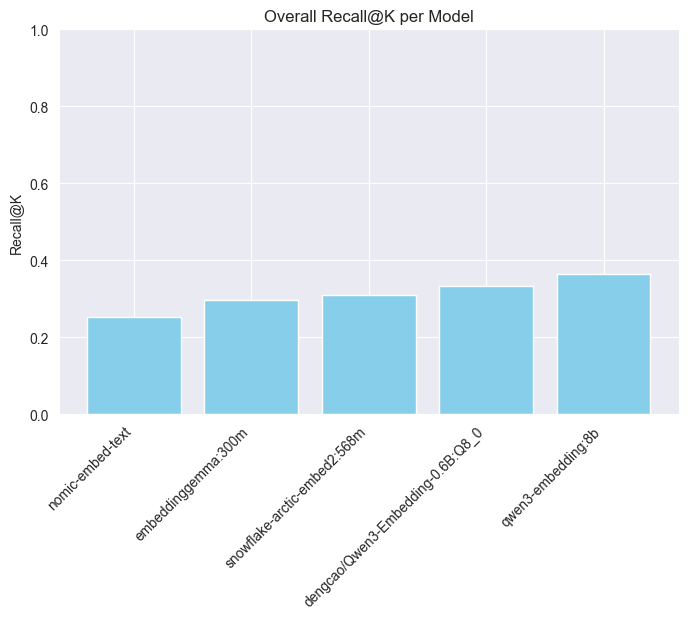

In [30]:
summary = pd.read_csv('./evaluation_data/summary_results.csv')

plt.figure(figsize=(8,5))
plt.bar(summary['model'], summary['recall_at_k'], color='skyblue')
plt.ylabel("Recall@K")
plt.title("Overall Recall@K per Model")
plt.xticks(rotation=45, ha='right')
plt.ylim(0,1)
plt.show()


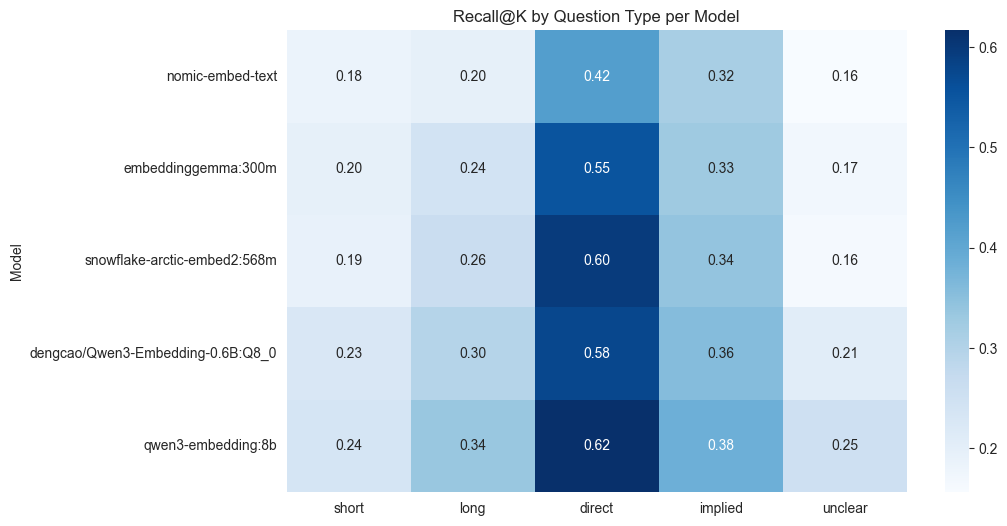

In [31]:
summary_expanded = summary.copy()
by_type_df = pd.json_normalize(summary_expanded['by_type'].apply(eval))
summary_expanded = pd.concat([summary_expanded[['model']], by_type_df], axis=1)

by_type_df = summary_expanded.set_index('model')

plt.figure(figsize=(10,6))
sns.heatmap(by_type_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Recall@K by Question Type per Model")
plt.ylabel("Model")
plt.show()


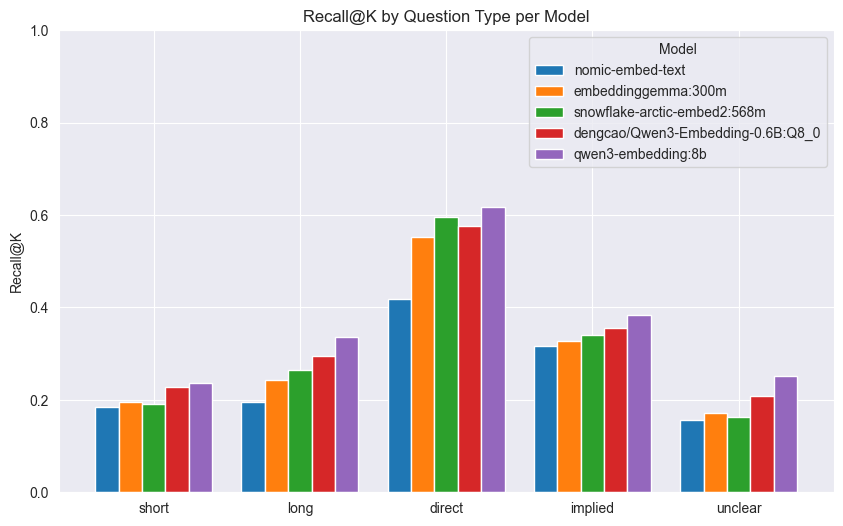

In [32]:
summary = pd.read_csv('./evaluation_data/summary_results.csv')
summary['by_type'] = summary['by_type'].apply(ast.literal_eval)
all_types = list(next(iter(summary['by_type'])))

data = {model: [summary.loc[i,'by_type'][qt] for qt in all_types]
        for i, model in enumerate(summary['model'])}

df = pd.DataFrame(data, index=all_types)

ax = df.plot(kind='bar', figsize=(10,6), width=0.8)
plt.ylabel("Recall@K")
plt.title("Recall@K by Question Type per Model")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(title="Model")
plt.show()
